In [86]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv("List of Countries by Sugarcane Production.csv")

In [43]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


In [44]:
df.shape

(103, 7)

# Data Cleaning 

In [45]:
df["Production (Tons)"] = df["Production (Tons)"].str.replace(".","")
df["Production per Person (Kg)"] = df["Production per Person (Kg)"].str.replace(".","").str.replace(",",".")
df["Acreage (Hectare)"] = df["Acreage (Hectare)"].str.replace(".","")
df["Yield (Kg / Hectare)"] = df["Yield (Kg / Hectare)"].str.replace(".","").str.replace(",",".")

In [46]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [47]:
df.rename(columns = {"Production (Tons)" : "Production(Tons)"},inplace = True)
df.rename(columns = {"Production per Person (Kg)" : "Production_per_Person_(Kg)"},inplace = True)
df.rename(columns = {"Acreage (Hectare)" : "Acreage_(Hectare)"},inplace = True)
df.rename(columns = {"Yield (Kg / Hectare)" : "Yield_(Kg / Hectare)"},inplace = True)

In [48]:
df

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879
...,...,...,...,...,...,...,...
98,98,Lebanon,Asia,97,16,3,28386.4
99,99,Djibouti,Africa,53,51,NaN,NaN
100,100,Singapore,Asia,50,9,2,25
101,101,Samoa,Oceania,12,6,1,11949.8


In [49]:
df.isnull().sum()

Unnamed: 0                    0
Country                       0
Continent                     0
Production(Tons)              0
Production_per_Person_(Kg)    0
Acreage_(Hectare)             1
Yield_(Kg / Hectare)          1
dtype: int64

In [50]:
df[df["Acreage_(Hectare)"].isnull()]

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare)
99,99,Djibouti,Africa,53,51,NaN,NaN


In [51]:
df.dropna(subset = ["Acreage_(Hectare)"],inplace = True)

In [52]:
df.isnull().sum()

Unnamed: 0                    0
Country                       0
Continent                     0
Production(Tons)              0
Production_per_Person_(Kg)    0
Acreage_(Hectare)             0
Yield_(Kg / Hectare)          0
dtype: int64

In [53]:
df[df["Acreage_(Hectare)"].isnull()]

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare)


In [54]:
df

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879
...,...,...,...,...,...,...,...
97,97,Spain,Europe,394,8,9,43596.5
98,98,Lebanon,Asia,97,16,3,28386.4
100,100,Singapore,Asia,50,9,2,25
101,101,Samoa,Oceania,12,6,1,11949.8


In [55]:
df.reset_index()

,index,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare)
0,0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,4,Pakistan,Asia,65450704,324219,1130820,57879
...,...,...,...,...,...,...,...,...
97,97,97,Spain,Europe,394,8,9,43596.5
98,98,98,Lebanon,Asia,97,16,3,28386.4
99,100,100,Singapore,Asia,50,9,2,25
100,101,101,Samoa,Oceania,12,6,1,11949.8


In [72]:
df.drop(columns = ["Unnamed: 0"],inplace = True)

In [73]:
df

,Country,Continent,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0
...,...,...,...,...,...,...
97,Spain,Europe,394.0,8.000,9.0,43596.5
98,Lebanon,Asia,97.0,16.000,3.0,28386.4
100,Singapore,Asia,50.0,9.000,2.0,25.0
101,Samoa,Oceania,12.0,6.000,1.0,11949.8


In [56]:
df.dtypes

Unnamed: 0                     int64
Country                       object
Continent                     object
Production(Tons)              object
Production_per_Person_(Kg)    object
Acreage_(Hectare)             object
Yield_(Kg / Hectare)          object
dtype: object

In [61]:
df["Production(Tons)"] = df["Production(Tons)"].astype(float)
df["Acreage_(Hectare)"] = df["Acreage_(Hectare)"].astype(float)
df["Yield_(Kg / Hectare)"] = df["Yield_(Kg / Hectare)"].astype(float)
df["Production_per_Person_(Kg)"] = df["Production_per_Person_(Kg)"].astype(float)

In [62]:
df.dtypes

Unnamed: 0                      int64
Country                        object
Continent                      object
Production(Tons)              float64
Production_per_Person_(Kg)    float64
Acreage_(Hectare)             float64
Yield_(Kg / Hectare)          float64
dtype: object

In [74]:
df.nunique()

Country                       102
Continent                       6
Production(Tons)              102
Production_per_Person_(Kg)    101
Acreage_(Hectare)             101
Yield_(Kg / Hectare)          102
dtype: int64

# Univariate Analysis

How many countries produce sugarcane from each continent

In [76]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


In [80]:
df["Continent"].value_counts()

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

# Distribution of columns

<Axes: xlabel='Continent', ylabel='Count'>

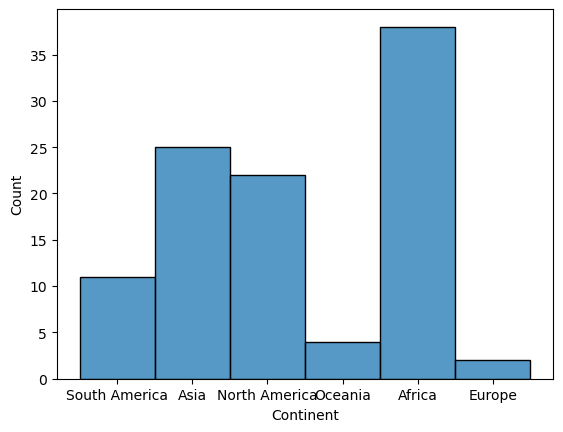

In [87]:
sns.histplot(df["Continent"])

OR

<Axes: xlabel='Continent'>

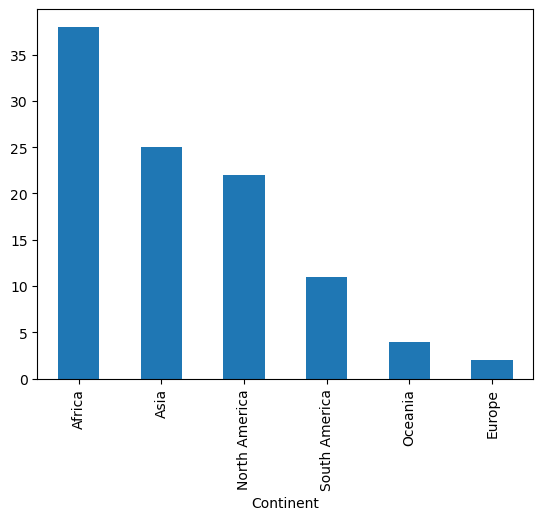

In [88]:
df["Continent"].value_counts().plot(kind = "bar")

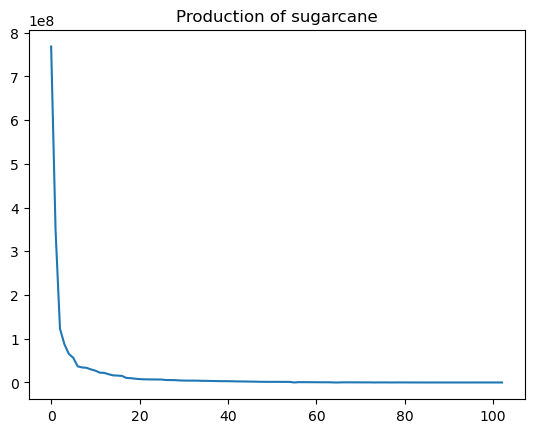

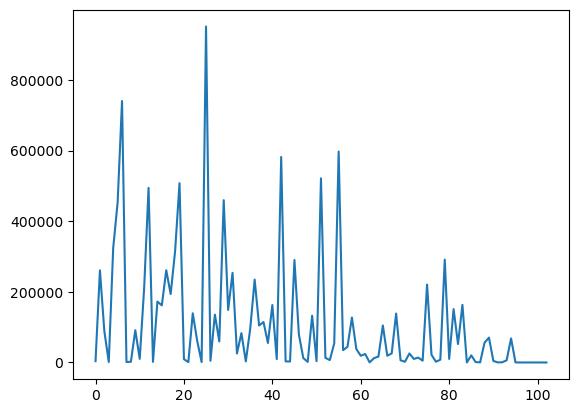

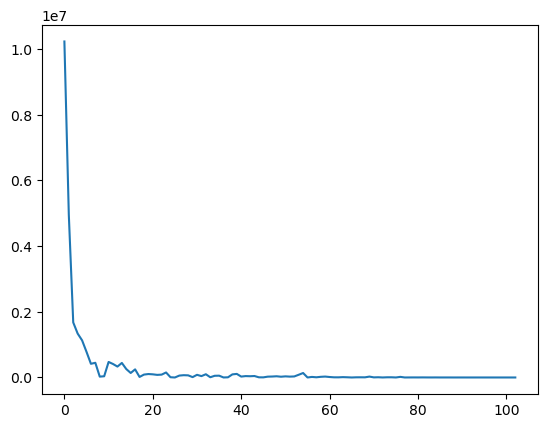

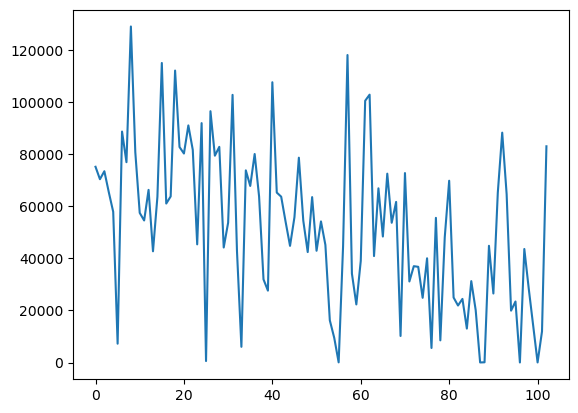

In [91]:
plt.figure()
plt.plot(df["Production(Tons)"])
plt.title("Production of sugarcane")

plt.figure()
plt.plot(df["Production_per_Person_(Kg)"])

plt.figure()
plt.plot(df["Acreage_(Hectare)"])

plt.figure()
plt.plot(df["Yield_(Kg / Hectare)"])

OR

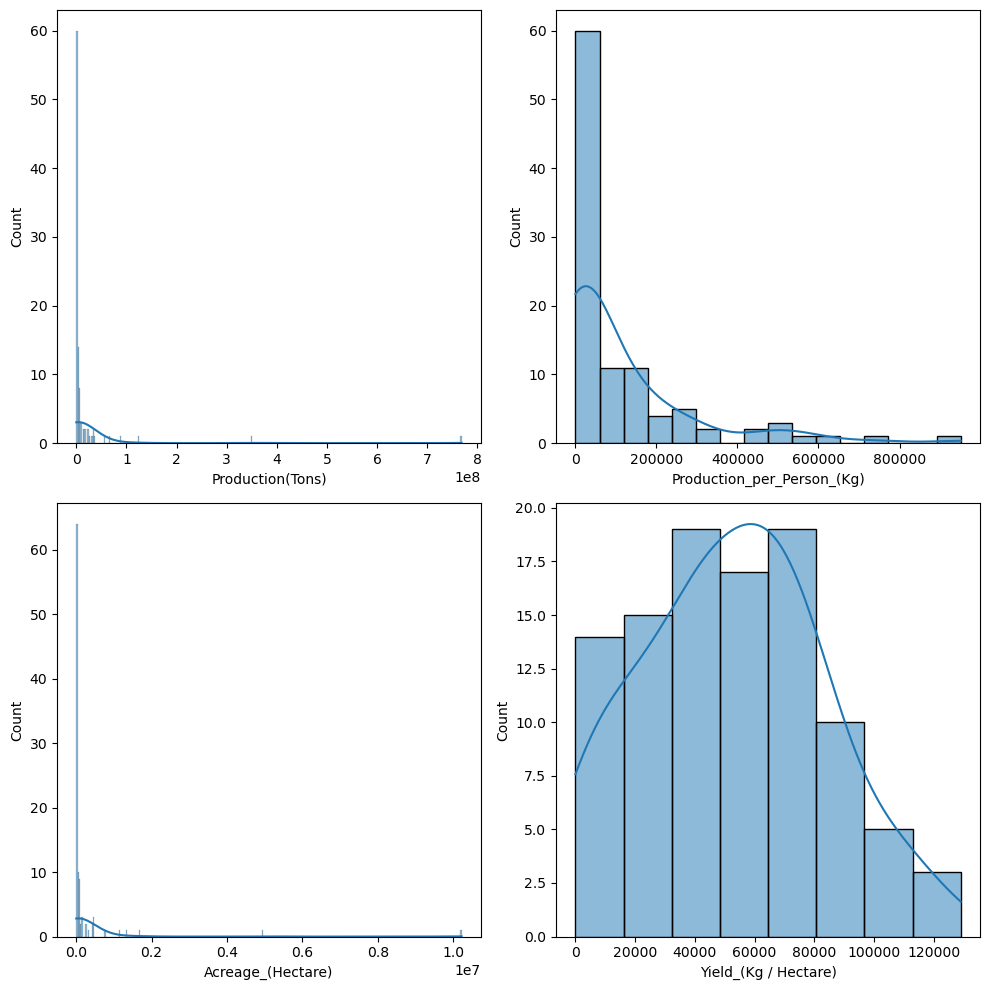

In [99]:
plt.figure(figsize = (10,10))

plt.subplot(2,2,1)
sns.histplot(df["Production(Tons)"],kde = True)

plt.subplot(2,2,2)
sns.histplot(df["Production_per_Person_(Kg)"],kde = True)

plt.subplot(2,2,3)
sns.histplot(df["Acreage_(Hectare)"],kde = True)

plt.subplot(2,2,4)
sns.histplot(df["Yield_(Kg / Hectare)"],kde = True)

plt.tight_layout()

# Checking Outliers

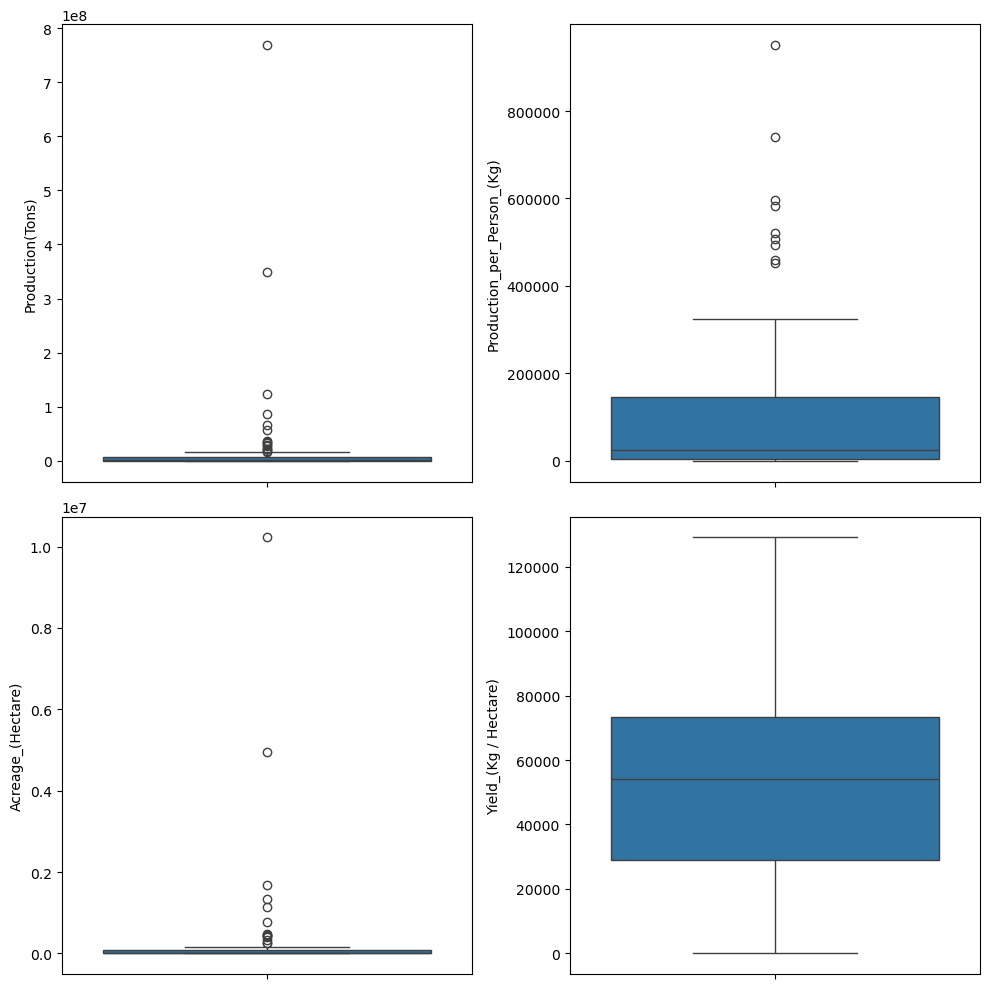

In [102]:
plt.figure(figsize = (10,10))

plt.subplot(2,2,1)
sns.boxplot(df["Production(Tons)"])

plt.subplot(2,2,2)
sns.boxplot(df["Production_per_Person_(Kg)"])

plt.subplot(2,2,3)
sns.boxplot(df["Acreage_(Hectare)"])

plt.subplot(2,2,4)
sns.boxplot(df["Yield_(Kg / Hectare)"])

plt.tight_layout()

In [103]:
df.describe()

,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare)
count,1.020000e+02,102.000000,1.020000e+02,102.000000
mean,1.850372e+07,112952.435755,2.498981e+05,52628.078431
std,8.419149e+07,176651.341929,1.137003e+06,30504.676683
min,1.000000e+00,0.000000,0.000000e+00,10.000000
25%,6.251875e+04,3671.910000,1.104000e+03,29072.025000
50%,1.440044e+06,25572.500000,1.655800e+04,54108.950000
75%,6.426824e+06,146384.750000,8.047400e+04,73282.700000
max,7.686784e+08,951087.000000,1.022620e+07,129049.300000


# Bivariate Analysis 

In [114]:
df_new = df[["Production(Tons)","Country"]].set_index("Country")

In [115]:
df_new

,Production(Tons)
Country,
Brazil,768678382.0
India,348448000.0
China,123059739.0
Thailand,87468496.0
Pakistan,65450704.0
...,...
Spain,394.0
Lebanon,97.0
Singapore,50.0


In [116]:
df_new["Production(Tons)_percent"] = df_new["Production(Tons)"] * 100 / df_new["Production(Tons)"].sum()

In [117]:
df_new

,Production(Tons),Production(Tons)_percent
Country,,
Brazil,768678382.0,4.072729e+01
India,348448000.0,1.846200e+01
China,123059739.0,6.520138e+00
Thailand,87468496.0,4.634389e+00
Pakistan,65450704.0,3.467809e+00
...,...,...
Spain,394.0,2.087551e-05
Lebanon,97.0,5.139401e-06
Singapore,50.0,2.649176e-06


In [118]:
df_new.describe()

,Production(Tons),Production(Tons)_percent
count,1.020000e+02,1.020000e+02
mean,1.850372e+07,9.803922e-01
std,8.419149e+07,4.460761e+00
min,1.000000e+00,5.298352e-08
25%,6.251875e+04,3.312463e-03
50%,1.440044e+06,7.629860e-02
75%,6.426824e+06,3.405157e-01
max,7.686784e+08,4.072729e+01


<Axes: ylabel='Production(Tons)_percent'>

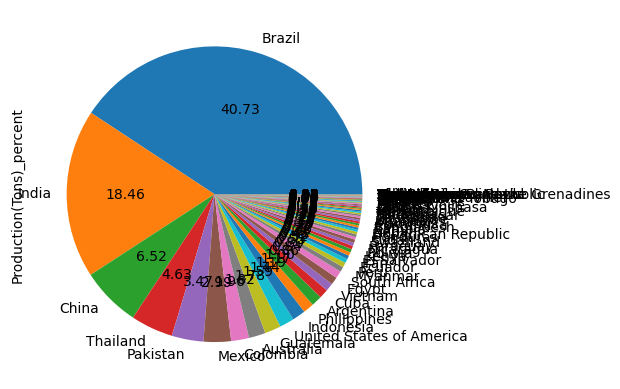

In [120]:
df_new["Production(Tons)_percent"].plot(kind = "pie" , autopct = "%.2f")

<Axes: xlabel='Country'>

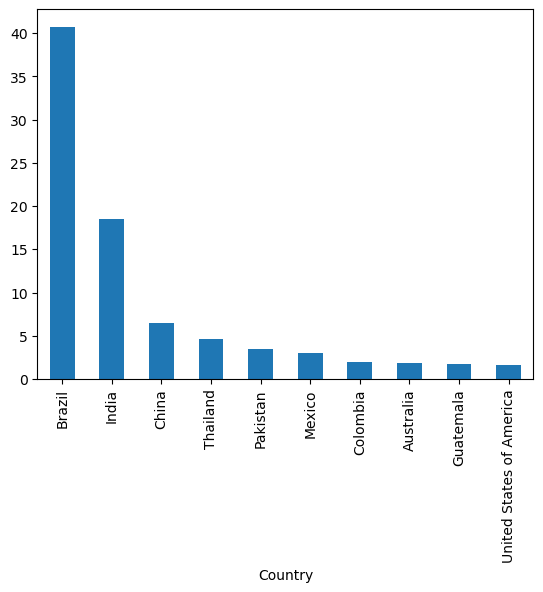

In [122]:
df_new["Production(Tons)_percent"].head(10).plot(kind = "bar")

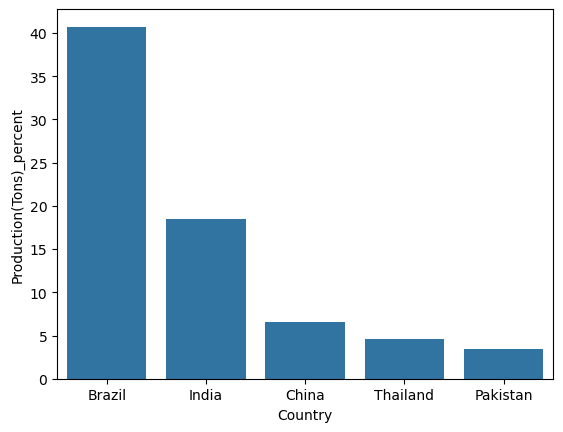

In [125]:
ax = sns.barplot(data = df_new.head() , x = "Country" , y = "Production(Tons)_percent")

C:\Users\Dhruv\AppData\Local\Temp\ipykernel_17240\3717412370.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax.get_xticklabels(),rotation = 90)


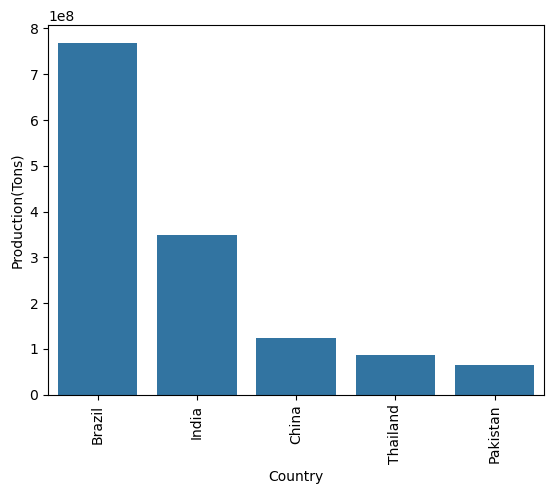

In [128]:
ax1 = sns.barplot(data = df.head() , x = "Country" , y = "Production(Tons)")
ax1.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

# Which country has the highest land

In [130]:
df10 = df.copy()

In [131]:
df10

,Country,Continent,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0
...,...,...,...,...,...,...
97,Spain,Europe,394.0,8.000,9.0,43596.5
98,Lebanon,Asia,97.0,16.000,3.0,28386.4
100,Singapore,Asia,50.0,9.000,2.0,25.0
101,Samoa,Oceania,12.0,6.000,1.0,11949.8


<Axes: >

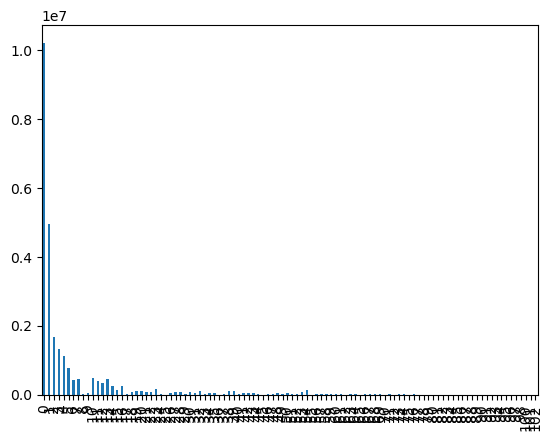

In [154]:
df10["Acreage_(Hectare)"].plot(kind = "bar")

In [155]:
df.loc[df["Acreage_(Hectare)"].idxmax()]

Country                              Brazil
Continent                     South America
Production(Tons)                768678382.0
Production_per_Person_(Kg)         3668.531
Acreage_(Hectare)                10226205.0
Yield_(Kg / Hectare)                75167.5
Name: 0, dtype: object

# Top 10 Countries having highest land

In [156]:
df11 = df.copy()

In [161]:
df11["Acreage_(Hectare)"] = df11["Acreage_(Hectare)"].sort_values(ascending = False)

<Axes: >

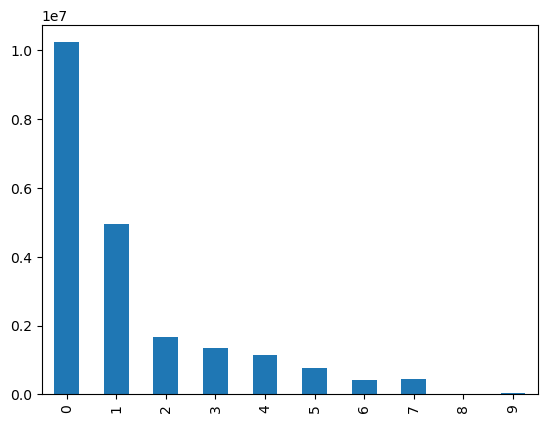

In [162]:
df11["Acreage_(Hectare)"].head(10).plot(kind = "bar")

# Which country has the highest Yield per Hectare

In [167]:
df11 = df.copy()

In [175]:
df11.loc[15]

Country                            Egypt
Continent                         Africa
Production(Tons)              15760418.0
Production_per_Person_(Kg)      161651.0
Acreage_(Hectare)               137011.0
Yield_(Kg / Hectare)            115030.6
Name: 15, dtype: object

<Axes: >

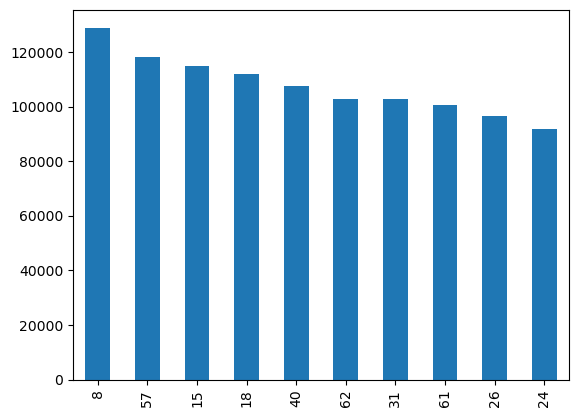

In [170]:
df11["Yield_(Kg / Hectare)"].sort_values(ascending = False).head(10).plot(kind = "bar")

In [148]:
df10.loc[df10["Yield_(Kg / Hectare)"].idxmax()]

Country                           Guatemala
Continent                     North America
Production(Tons)                 33533403.0
Production_per_Person_(Kg)         1938.114
Acreage_(Hectare)                   25985.0
Yield_(Kg / Hectare)               129049.3
Name: 8, dtype: object

# Which country has the highest production

In [149]:
df10.loc[df10["Production(Tons)"].idxmax()]

Country                              Brazil
Continent                     South America
Production(Tons)                768678382.0
Production_per_Person_(Kg)         3668.531
Acreage_(Hectare)                10226205.0
Yield_(Kg / Hectare)                75167.5
Name: 0, dtype: object

# Correlation

In [177]:
df.select_dtypes(include="number").corr()

,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare)
Production(Tons),1.000000,0.015000,0.997550,0.132812
Production_per_Person_(Kg),0.015000,1.000000,0.012557,0.017999
Acreage_(Hectare),0.997550,0.012557,1.000000,0.113433
Yield_(Kg / Hectare),0.132812,0.017999,0.113433,1.000000


# Do countries with highest land produce more sugarcane ?

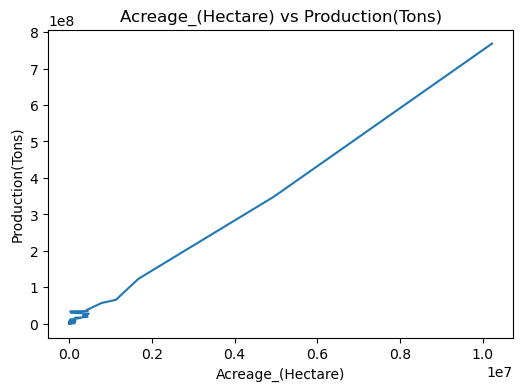

In [182]:
x_col = "Acreage_(Hectare)"
y_col = "Production(Tons)"

plt.figure(figsize=(6,4))
plt.plot(df[x_col], df[y_col])
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f"{x_col} vs {y_col}")
plt.show()


As we can see, people with higher land produce high amount of sugarcane 

<Axes: >

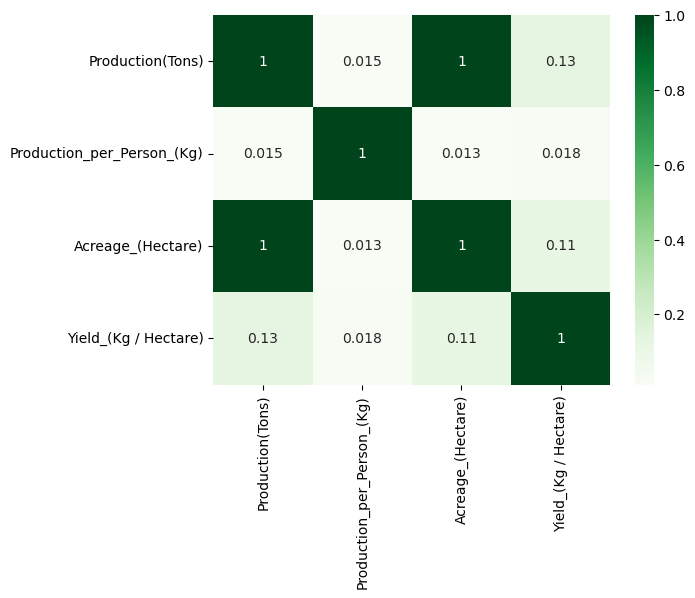

In [186]:
sns.heatmap(df.select_dtypes(include = "number").corr(),annot = True,cmap = "Greens")

<Axes: xlabel='Acreage_(Hectare)', ylabel='Production(Tons)'>

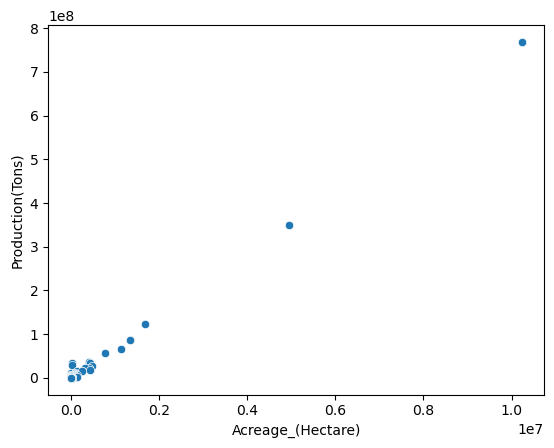

In [188]:
sns.scatterplot(x = df["Acreage_(Hectare)"],y = df["Production(Tons)"])

# Do countries which yield more sugarcane per hectare produces more sugarcane in total?

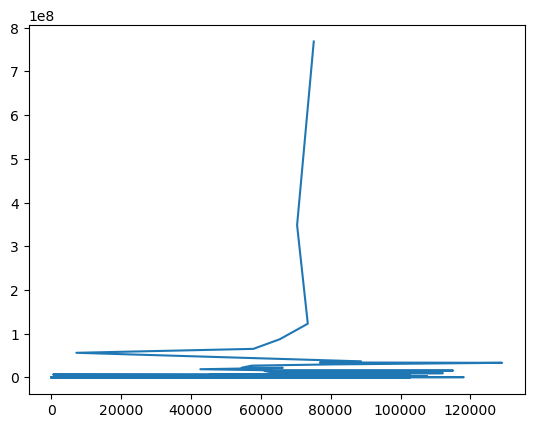

In [181]:
plt.plot(df["Yield_(Kg / Hectare)"],df["Production(Tons)"])

<Axes: xlabel='Yield_(Kg / Hectare)', ylabel='Production(Tons)'>

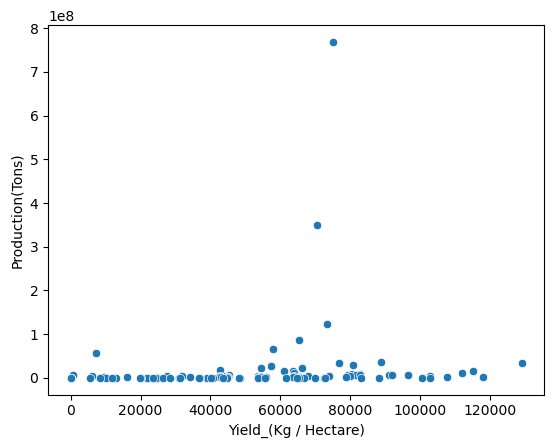

In [189]:
sns.scatterplot(x = df["Yield_(Kg / Hectare)"] , y = df["Production(Tons)"])

In [190]:
# No, there is no connection between these two 

# ANALYSIS FOR CONTINENTS 

# Which continent produces maximum sugarcane

In [191]:
df12 = df.copy()

In [193]:
df12

,Country,Continent,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0
...,...,...,...,...,...,...
97,Spain,Europe,394.0,8.000,9.0,43596.5
98,Lebanon,Asia,97.0,16.000,3.0,28386.4
100,Singapore,Asia,50.0,9.000,2.0,25.0
101,Samoa,Oceania,12.0,6.000,1.0,11949.8


In [203]:
df12.sort_values(by = "Production(Tons)" , ascending= False,inplace = True)

<Axes: xlabel='Continent'>

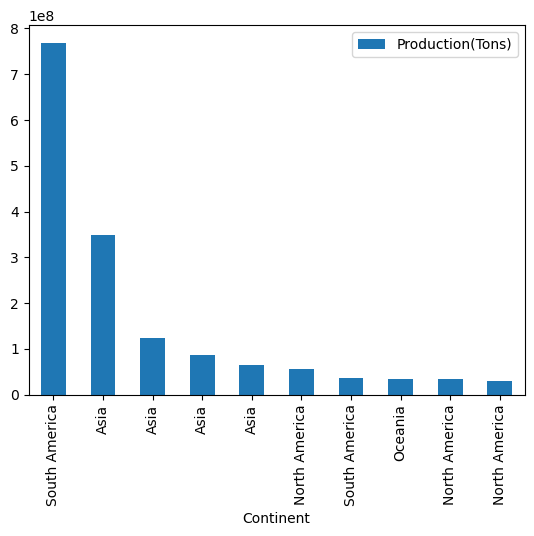

In [205]:
df12.head(10).plot(x = "Continent",y = "Production(Tons)",kind = "bar")

# OR

In [222]:
df_continent = df.groupby("Continent").sum()

In [235]:
df_continent["number_of_countries"] = df.groupby("Continent").count()["Country"]

In [236]:
df_continent

,Country,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare),number_of_countries
Continent,,,,,,
Africa,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681472.0,2332636.293,1439089.0,2142107.5,38
Asia,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425.0,1857769.303,10608319.0,1171871.4,25
Europe,PortugalSpain,5823.0,536.000,71.0,131870.9,2
North America,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947.0,3796081.508,1581983.0,1082602.4,22
Oceania,AustraliaFijiPapua New GuineaSamoa,36177574.0,28593.605,490909.0,162419.1,4
South America,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126.0,3505531.738,11369236.0,677192.7,11


<Axes: xlabel='Continent'>

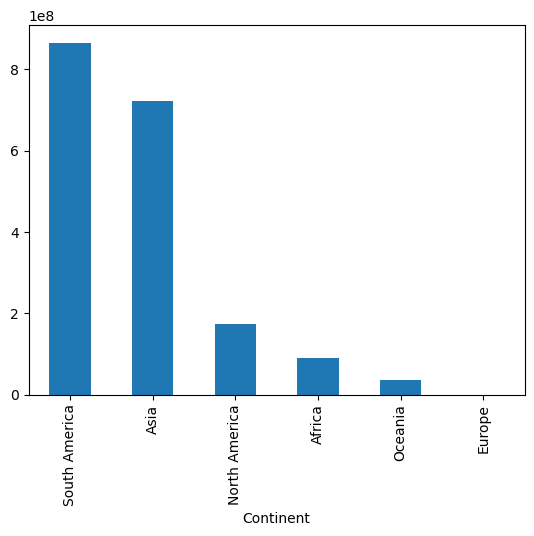

In [214]:
df_continent["Production(Tons)"].sort_values(ascending = False).plot(kind = "bar")

# How many countries are there in each continent 

In [219]:
df["Continent"].value_counts()

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

# Do number of countries in a Continent affects production of sugarcane?

In [234]:
# No, as although Africa as most countries, still highest production is done by South America
df_continent

,Country,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare)
Continent,,,,,
Africa,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681472.0,2332636.293,1439089.0,2142107.5
Asia,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425.0,1857769.303,10608319.0,1171871.4
Europe,PortugalSpain,5823.0,536.000,71.0,131870.9
North America,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947.0,3796081.508,1581983.0,1082602.4
Oceania,AustraliaFijiPapua New GuineaSamoa,36177574.0,28593.605,490909.0,162419.1
South America,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126.0,3505531.738,11369236.0,677192.7


In [225]:
continent_names = df_continent.index.to_list()

# It makes a list of index of df_continent i.e name of continents

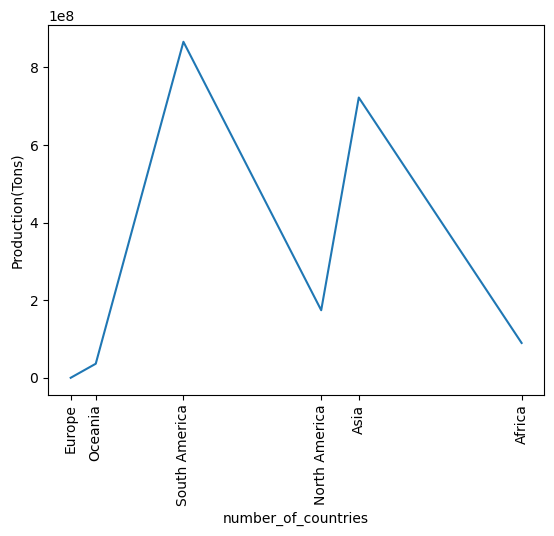

In [237]:
sns.lineplot(data = df_continent,x = "number_of_countries", y= "Production(Tons)" )
plt.xticks(df_continent["number_of_countries"], continent_names, rotation =90)
plt.show()

# Do continent with highest land produces more sugarcane?

<Axes: xlabel='Acreage_(Hectare)', ylabel='Production(Tons)'>

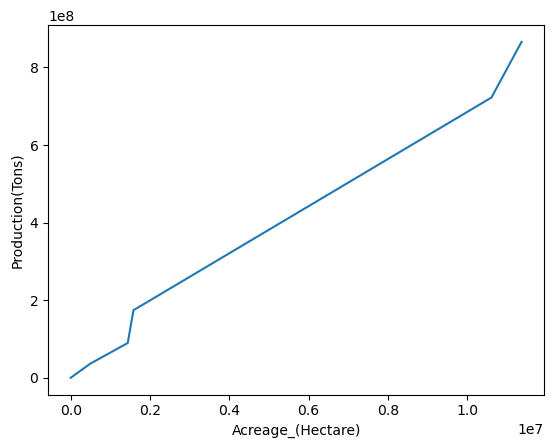

In [239]:
sns.lineplot(data = df_continent,x = "Acreage_(Hectare)",y = "Production(Tons)")

# Production distribution by continent

<Axes: ylabel='Production(Tons)'>

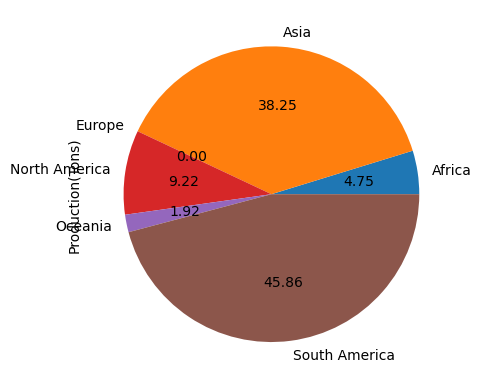

In [243]:
df_continent["Production(Tons)"].plot(kind = "pie",autopct = "%.2f")

# Correlation for continents

In [241]:
df_continent.select_dtypes(include="number").corr()

,Production(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg / Hectare),number_of_countries
Production(Tons),1.000000,0.522211,0.994897,0.091201,0.109244
Production_per_Person_(Kg),0.522211,1.000000,0.463215,0.542961,0.540086
Acreage_(Hectare),0.994897,0.463215,1.000000,0.111166,0.132817
Yield_(Kg / Hectare),0.091201,0.542961,0.111166,1.000000,0.989712
number_of_countries,0.109244,0.540086,0.132817,0.989712,1.000000


<Axes: >

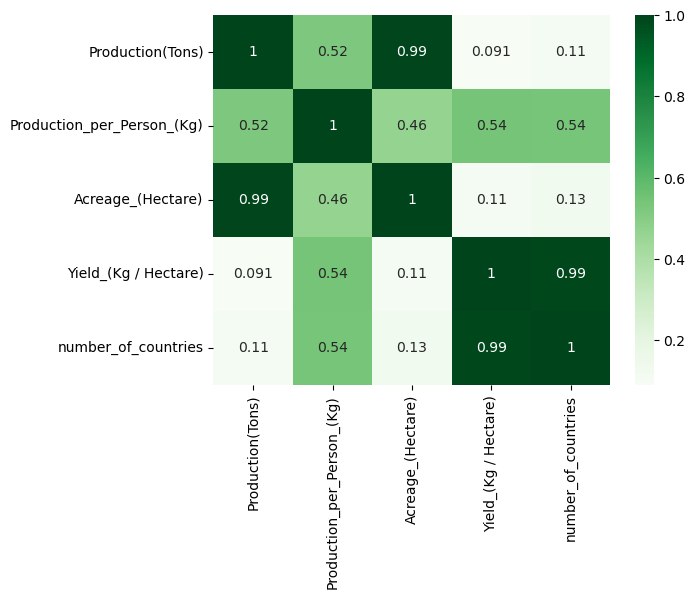

In [242]:
sns.heatmap(df_continent.select_dtypes(include = "number").corr(),annot = True,cmap = "Greens")